In [192]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

**Move through the datasets to know what is needed to be cleaned combined or modified**

In [193]:
df1 = pd.read_csv('../data/daily_sales_data_0.csv')
print('df1 header', df1.head)
df2 = pd.read_csv('../data/daily_sales_data_1.csv')
print('df2 header', df2.head)
df3 = pd.read_csv('../data/daily_sales_data_2.csv')
print('df3 header', df3.head)

df1 header <bound method NDFrame.head of                 product  price  quantity        date region
0           pink morsel  $3.00       546  2018-02-06  north
1           pink morsel  $3.00       549  2018-02-06  south
2           pink morsel  $3.00       577  2018-02-06   east
3           pink morsel  $3.00       519  2018-02-06   west
4           gold morsel  $9.99       580  2018-02-06  north
...                 ...    ...       ...         ...    ...
13715  vermilion morsel  $4.99       504  2019-06-10   west
13716      lapis morsel  $1.99       521  2019-06-10  north
13717      lapis morsel  $1.99       502  2019-06-10  south
13718      lapis morsel  $1.99       536  2019-06-10   east
13719      lapis morsel  $1.99       515  2019-06-10   west

[13720 rows x 5 columns]>
df2 header <bound method NDFrame.head of                 product  price  quantity        date region
0           pink morsel  $3.00       545  2019-06-11  north
1           pink morsel  $3.00       521  2019-06-1

**Since they all have the same 4 columns which are the targeted ones then they will be combined but first lets check for each dataset data types to see if any cleaning is needed per dataset**

In [194]:
print('d1 datatypes and null count', df1.dtypes, df1.isnull().sum())
print('d2 datatypes and null count', df2.dtypes, df2.isnull().sum())
print('d3 datatypes and null count', df3.dtypes, df3.isnull().sum())

#since the price is always a string and we can't know if the string is always a valid one we will do a fast check on it
#first make a new column that will have the price tags changed to float number to be usable with coerce to find the invalid prices
df1['price_num'] = pd.to_numeric(df1['price'].str.replace('$', '').replace(',', ''), errors='coerce')
df2['price_num'] = pd.to_numeric(df1['price'].str.replace('$', '').replace(',', ''), errors='coerce')
df3['price_num'] = pd.to_numeric(df1['price'].str.replace('$', '').replace(',', ''), errors='coerce')

print('df1 invalid values', df1['price_num'].isna().sum())
print('df2 invalid values', df2['price_num'].isna().sum())
print('df3 invalid values', df3['price_num'].isna().sum())

#for the last cleaning move lets ensure that all the products are in lowercase so we won't leave some data untoched

df1['product'] = df1['product'].str.lower()
df2['product'] = df2['product'].str.lower()
df3['product'] = df3['product'].str.lower()


d1 datatypes and null count product       str
price         str
quantity    int64
date          str
region        str
dtype: object product     0
price       0
quantity    0
date        0
region      0
dtype: int64
d2 datatypes and null count product       str
price         str
quantity    int64
date          str
region        str
dtype: object product     0
price       0
quantity    0
date        0
region      0
dtype: int64
d3 datatypes and null count product       str
price         str
quantity    int64
date          str
region        str
dtype: object product     0
price       0
quantity    0
date        0
region      0
dtype: int64
df1 invalid values 0
df2 invalid values 0
df3 invalid values 0


**Now the data is all valid and we can work with it we will create the new table which is date, sales and region from the 3 datasets**

In [195]:
#first I will create the dataframe 
dfFinal = pd.DataFrame(columns=['sales', 'region', 'date']).astype({
    'sales': 'float64',
    'region': 'str', 
    'date': 'str'
})

#add the elements inside the prev dataframes to the newly created one

dfsPrev = [df1, df2, df3]

dfTemp = [] 

for dfPrev in dfsPrev:
    dfFiltered = dfPrev[dfPrev['product'] == 'pink morsel']
    tempdf = pd.DataFrame({
        'date': pd.to_datetime(dfFiltered['date']),
        'region': dfFiltered['region'],
        'sales': dfFiltered['quantity'] * dfFiltered['price_num']
    })

    dfTemp.append(tempdf)

dfFinal = pd.concat([dfFinal] + dfTemp, ignore_index= True)

**Final Dataframe shape**

In [196]:
print(dfFinal)
dfFinal.to_csv('../data/PinkMorselSales.csv', index=False)

       sales region                 date
0     1638.0  north  2018-02-06 00:00:00
1     1647.0  south  2018-02-06 00:00:00
2     1731.0   east  2018-02-06 00:00:00
3     1557.0   west  2018-02-06 00:00:00
4     1587.0  north  2018-02-07 00:00:00
...      ...    ...                  ...
5875  1434.0   west  2022-02-13 00:00:00
5876  1221.0  north  2022-02-14 00:00:00
5877  1479.0  south  2022-02-14 00:00:00
5878  1500.0   east  2022-02-14 00:00:00
5879  1269.0   west  2022-02-14 00:00:00

[5880 rows x 3 columns]


**Grouped by date for better visualization**

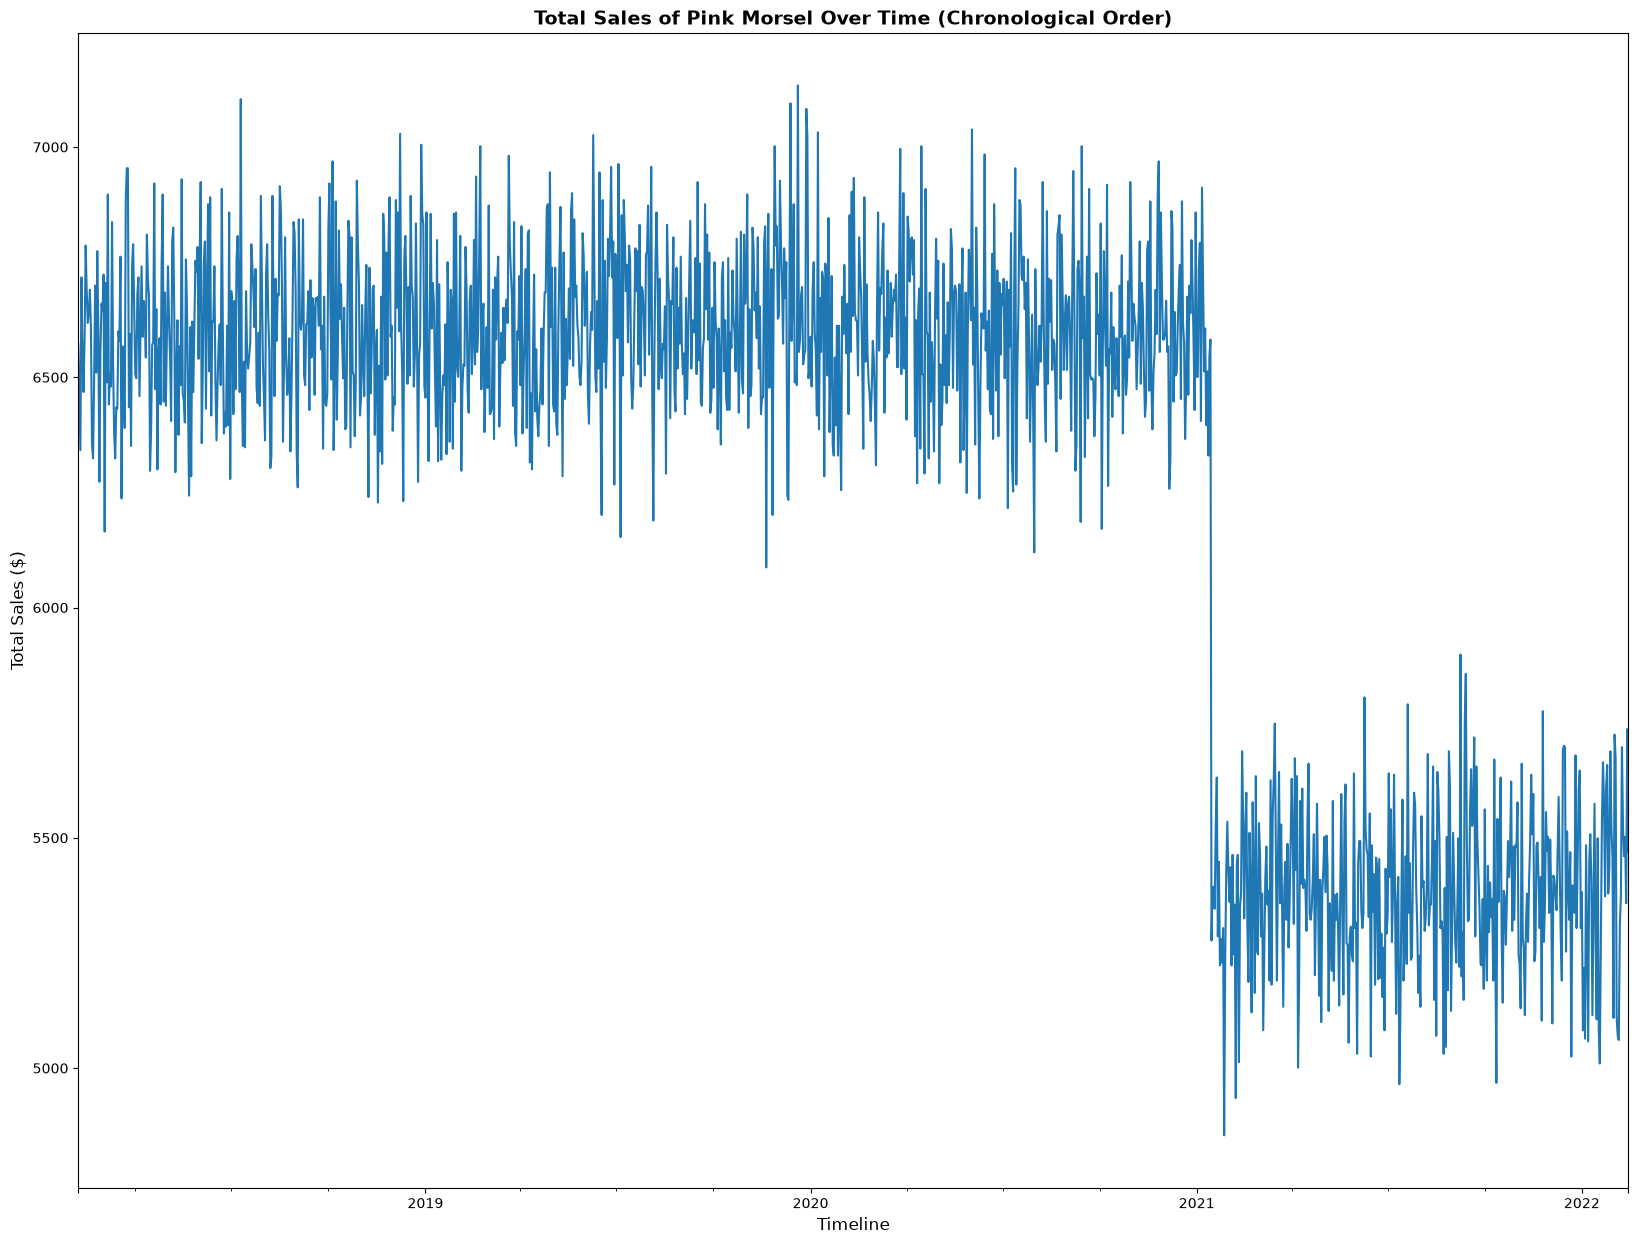

In [197]:
dfFinal.sort_values('date').groupby('date')['sales'].sum().plot(kind= 'line', figsize= (20, 15))

plt.title('Total Sales of Pink Morsel Over Time (Chronological Order)', fontsize=14, fontweight='bold')
plt.xlabel('Timeline', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)

plt.show()


**Grouping by region and date for another visualization**

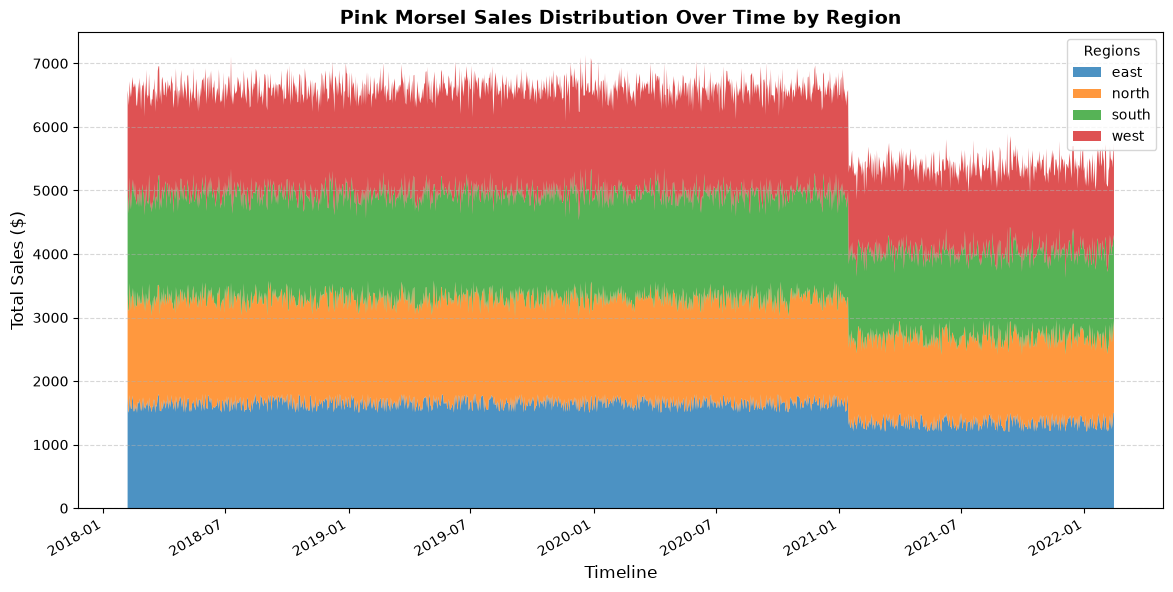

In [198]:
df_pivot = dfFinal.groupby(['date', 'region'])['sales'].sum().unstack(level='region').sort_index()

plt.figure(figsize=(14, 7))
plt.stackplot(df_pivot.index, [df_pivot[col] for col in df_pivot.columns], labels=df_pivot.columns, alpha=0.8)

plt.title('Pink Morsel Sales Distribution Over Time by Region', fontsize=14, fontweight='bold')
plt.xlabel('Timeline', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.legend(title='Regions', loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.gcf().autofmt_xdate() 